In [105]:
import os
import glob
from PIL import Image
import numpy as np
import torchvision
from torch.utils.data import Dataset, DataLoader
import torch
from torch import nn, optim
from tqdm import tqdm

# Custom segmentation training cell
# Assumes `torch`, `nn`, `optim` were already imported in a previous cell.

import torchvision.transforms as T

# -------------------------
# Dataset
# -------------------------
class SegmentationDataset(Dataset):
    """
    Expects:
      - images_dir: files like /path/to/images/img_001.jpg
      - masks_dir:  files like /path/to/masks/img_001.png
    Masks should contain integer class ids per pixel (0..num_classes-1).
    """
    def __init__(self, images_dir, masks_dir, image_size=(320, 320), augment=False):
        self.images = sorted(glob.glob(os.path.join(images_dir, "*")))
        self.masks = sorted(glob.glob(os.path.join(masks_dir, "*")))
        assert len(self.images) == len(self.masks), "Mismatched number of images and masks"
        self.image_size = image_size
        self.augment = augment

        # image transform
        self.img_transform = T.Compose([
            T.Resize(self.image_size, interpolation=Image.BILINEAR),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],  # standard ImageNet
                        std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("L")
        img = img.convert("RGB")  # convert grayscale to 3-channel RGB
        mask = Image.open(self.masks[idx]).convert("L")  # single-channel with class ids
        # Binarize mask: pixels >= 128 -> 1, else 0
        threshold = 128
        mask = mask.point(lambda p: 1 if p >= threshold else 0)

        # Optional simple augmentation (flip)
        if self.augment and np.random.rand() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        img = self.img_transform(img)
        # resize mask with nearest to keep integer labels
        mask = mask.resize(self.image_size, resample=Image.NEAREST)
        mask = torch.from_numpy(np.array(mask, dtype=np.int64)).long()  # assuming 255 is ignore index
        return img, mask

# -------------------------
# Metrics
# -------------------------
def compute_iou(pred, target, num_classes, ignore_index=None):
    # pred: (N,H,W) int, target: (N,H,W) int
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    for cls in range(num_classes):
        if ignore_index is not None and cls == ignore_index:
            continue
        pred_inds = (pred == cls)
        target_inds = (target == cls)
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))  # class not present in batch
        else:
            ious.append(intersection / union)
    # return mean IoU ignoring NaNs
    ious = [v for v in ious if not np.isnan(v)]
    return float(np.mean(ious)) if ious else 0.0

# -------------------------
# Model creation helper
# -------------------------
def create_model(num_classes, pretrained=False, pretrained_backbone=False):
    # Using DeepLabV3 with ResNet50 backbone; change to other models if desired
    model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=pretrained, progress=True)
    # replace classifier to match num_classes
    model.classifier[-1] = torch.nn.Conv2d(256, num_classes, kernel_size=1)
    # optionally load pretrained backbone weights
    if pretrained_backbone:
        # load backbone pretrained weights only (example approach)
        backbone = torchvision.models.resnet50(pretrained=True)
        model.backbone.load_state_dict({k.replace('layer1.', 'layer1.'): v for k, v in backbone.state_dict().items() if k in model.backbone.state_dict()}, strict=False)
    return model


def create_class_balanced_dataloader(dataset, batch_size, zonal_labels, oversampling_ratio=0.8):
    assert 0.0 <= oversampling_ratio <= 1.0, "oversampling_ratio should be in (0,1)"
    # list of basenames for quick membership checks
    mask_basenames = [os.path.basename(p) for p in dataset.masks]
    zonal_set = set(zonal_labels)

    # per-sample weights: higher for zonal samples
    weights = [oversampling_ratio if name in zonal_set else (1.0 - oversampling_ratio) for name in mask_basenames]
    weights_tensor = torch.as_tensor(weights, dtype=torch.double)

    # Weighted sampler (replacement=True to allow oversampling)
    sampler = torch.utils.data.WeightedRandomSampler(weights=weights_tensor, num_samples=len(weights_tensor), replacement=True)

    # DataLoader using the sampler
    imbalanced_loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, num_workers=4, pin_memory=True)

    return imbalanced_loader

# -------------------------
# Training loop
# -------------------------
def train_segmentation(
    train_images_dir,
    train_masks_dir,
    val_images_dir=None,
    val_masks_dir=None,
    num_classes=2,
    pretrained=False,
    image_size=(320,320),
    batch_size=8,
    lr=1e-4,
    weight_decay=1e-5,
    num_epochs=20,
    oversampling_ratio=0.8,
    device=None,
    save_path="seg_model.pth",
    zonal_labels=None
):
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    train_ds = SegmentationDataset(train_images_dir, train_masks_dir, image_size=image_size, augment=False)
    if zonal_labels is None:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    else:
        train_loader = create_class_balanced_dataloader(train_ds, batch_size, zonal_labels, oversampling_ratio=oversampling_ratio)

    val_loader = None
    if val_images_dir and val_masks_dir:
        val_ds = SegmentationDataset(val_images_dir, val_masks_dir, image_size=image_size, augment=False)
        if zonal_labels is None:
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
        else:
            val_loader = create_class_balanced_dataloader(val_ds, batch_size, zonal_labels, oversampling_ratio=oversampling_ratio)


    model = create_model(num_classes=num_classes, pretrained=pretrained).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, masks in tqdm(train_loader):
            imgs = imgs.to(device)
            masks = masks.to(device)  # shape (N,H,W), dtype long
            optimizer.zero_grad()
            out = model(imgs)['out']  # (N,C,H,W)
            loss = criterion(out, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        scheduler.step()
        epoch_loss = running_loss / len(train_loader.dataset)
        msg = f"Epoch {epoch}/{num_epochs} - train loss: {epoch_loss:.4f}"

        if val_loader:
            model.eval()
            with torch.no_grad():
                total_iou = 0.0
                n_batches = 0
                for imgs, masks in val_loader:
                    imgs = imgs.to(device)
                    masks = masks.to(device)
                    out = model(imgs)['out']
                    preds = out.argmax(dim=1)  # (N,H,W)
                    total_iou += compute_iou(preds.cpu(), masks.cpu(), num_classes)
                    n_batches += 1
                mean_iou = total_iou / n_batches if n_batches else 0.0
            msg += f" - val mIoU: {mean_iou:.4f}"
        print(msg)

        # save checkpoint
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'num_classes': num_classes
        }, save_path)

    return model

In [106]:
import shutil

raw_data_path = 'data/volume_500'

data_path = 'data'

zonal_labels = []

# create train and val directories if they don't exist
train_img_dir = os.path.join(data_path, 'train', 'images')
train_mask_dir = os.path.join(data_path, 'train', 'masks')
val_img_dir = os.path.join(data_path, 'val', 'images')
val_mask_dir = os.path.join(data_path, 'val', 'masks')

os.makedirs(train_img_dir, exist_ok=True)
os.makedirs(train_mask_dir, exist_ok=True)
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_mask_dir, exist_ok=True)

directories = sorted([e for e in os.listdir(raw_data_path) if os.path.isdir(os.path.join(raw_data_path, e))])
img_directories = list()
mask_directories = list()
for d in directories:
    if '_zonal_seg' in d:
        mask_directories.append(os.path.join(raw_data_path, d))
        with open(os.path.join(raw_data_path, f'{d}.txt'), 'r') as f:
            zonal_labels += [line.strip().split('/')[-1] for line in f.readlines()]
    else:
        img_directories.append(os.path.join(raw_data_path, d))

for img_dir, mask_dir in zip(img_directories, mask_directories):
    img_files = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, '*.jpg')))

    # split 80% train, 20% val
    split_idx = int(0.8 * len(img_files))
    train_img_files = img_files[:split_idx]
    train_mask_files = mask_files[:split_idx]
    val_img_files = img_files[split_idx:]
    val_mask_files = mask_files[split_idx:]

    # copy files to their respective directories
    for f in train_img_files:
        shutil.copy(f, train_img_dir)
    for f in train_mask_files:
        shutil.copy(f, train_mask_dir)
    for f in val_img_files:
        shutil.copy(f, val_img_dir)
    for f in val_mask_files:
        shutil.copy(f, val_mask_dir)


In [107]:
model = train_segmentation(
    train_images_dir=train_img_dir,
    train_masks_dir=train_mask_dir,
    val_images_dir=val_img_dir,
    val_masks_dir=val_mask_dir,
    num_classes=2,
    image_size=(512,512),
    batch_size=4,
    pretrained=True,
    num_epochs=4,
    save_path="deeplab_custom.pth",
    zonal_labels=zonal_labels,
    oversampling_ratio=1.0,
)

/home/jenia/anaconda3/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jenia/anaconda3/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 400/400 [04:37<00:00,  1.44it/s]


Epoch 1/4 - train loss: 0.1440 - val mIoU: 0.4984


100%|██████████| 400/400 [05:04<00:00,  1.32it/s]


Epoch 2/4 - train loss: 0.0284 - val mIoU: 0.5798


100%|██████████| 400/400 [05:11<00:00,  1.29it/s]


Epoch 3/4 - train loss: 0.0162 - val mIoU: 0.5736


100%|██████████| 400/400 [05:13<00:00,  1.28it/s]


Epoch 4/4 - train loss: 0.0118 - val mIoU: 0.6511


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


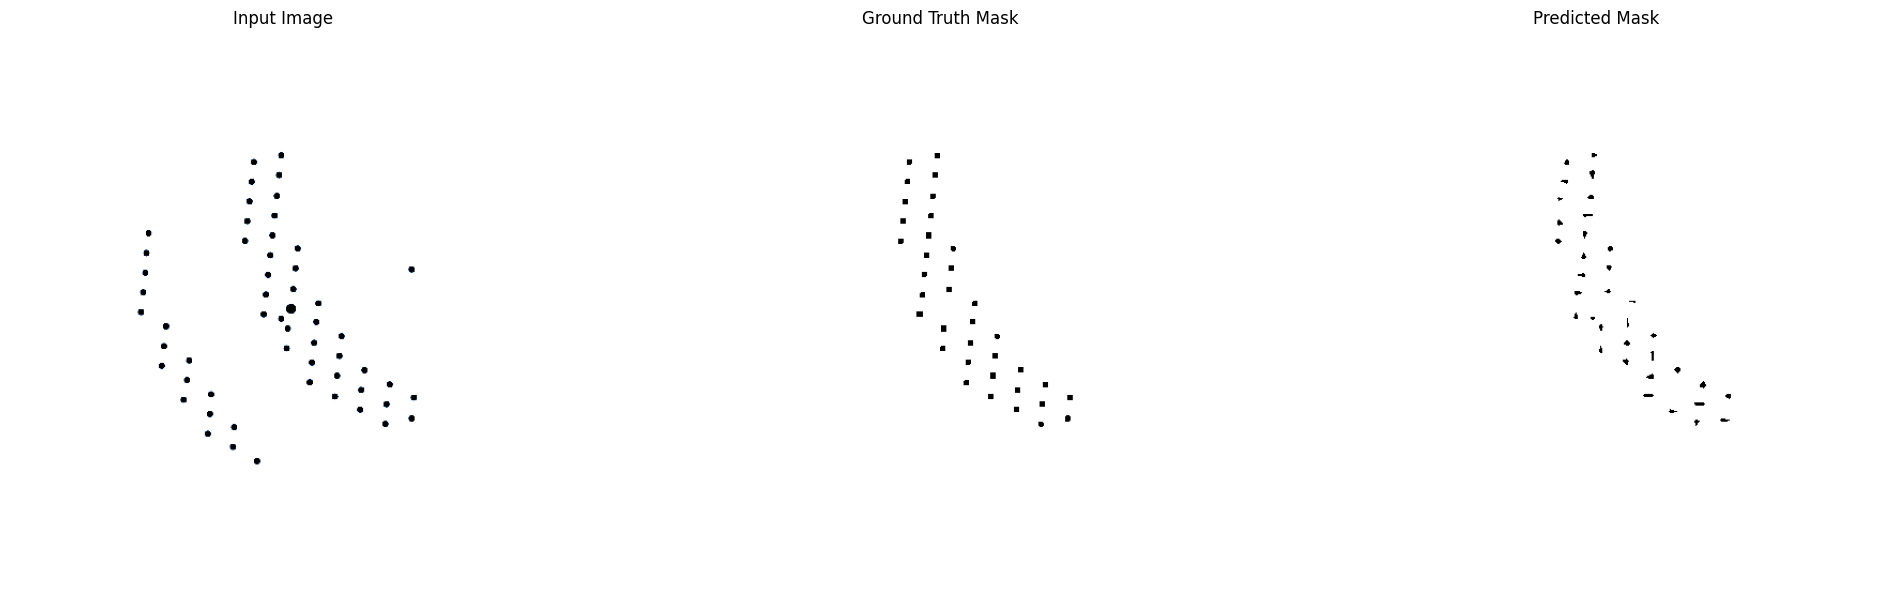

In [110]:
ds = SegmentationDataset(val_img_dir, val_mask_dir, image_size=(512,512), augment=True)
cb_dl = create_class_balanced_dataloader(ds, batch_size=4, zonal_labels=zonal_labels, oversampling_ratio=1.0)
batch = next(iter(cb_dl))
imgs, masks = batch
with torch.no_grad():
    model.eval()
    out = model(imgs.cuda())['out']  # add batch dim
    preds = out.argmax(dim=1)  # (1,H,W)

import matplotlib.pyplot as plt

plt.figure(figsize=(24,12))
plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(imgs[0].permute(1,2,0).cpu().numpy())
plt.axis('off')
plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(masks[0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(preds[0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.show()

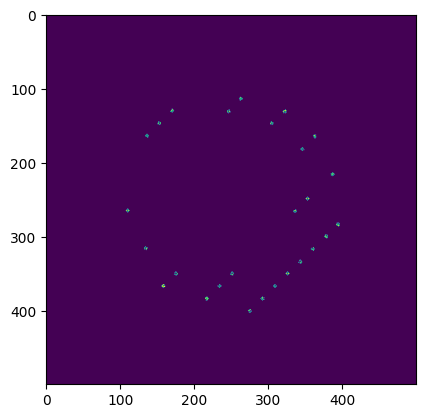

In [96]:
import cv2

zonal_sample = [ds.masks[i] for i in range(len(ds)) if os.path.basename(ds.masks[i]) in zonal_labels]
mask = np.array(Image.open(zonal_sample[0]).convert("L")) == 0
# mask = cv2.resize(mask.astype(np.uint8), ds.image_size, interpolation=cv2.INTER_NEAREST)

mask = torch.from_numpy(mask).long()  # assuming 255 is ignore index
plt.imshow(mask)